In [1]:
import os
from subshowers import subshowers, plotting, showers
from matplotlib import pyplot as plt
import IPython
import numpy as np
import yaml
conf_path = "subshowers/configs/default.yaml"
with open(conf_path, 'r') as f:
    conf = yaml.safe_load(f)

shower_files = showers.ShowerFolders(conf)
print(f"Found {len(shower_files)} showers")


Found 4 showers


Text(0.5, 1.0, 'Total points 4829167')

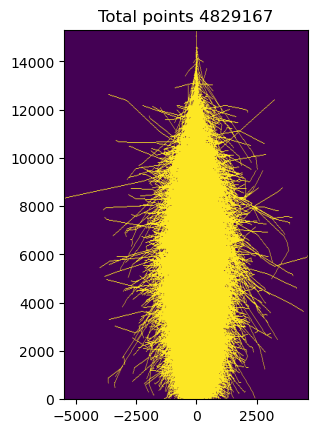

In [2]:
reader = showers.Reader(shower_files[0])
total_points = len(reader)

overview = plotting.Overview(reader)
extent = [overview.x_bins[0], overview.x_bins[-1], overview.y_bins[0], overview.y_bins[-1]]
plt.imshow(overview.grid, origin="lower", extent=extent)
plt.title(f"Total points {total_points}")

In [3]:
subshower_energy = 500
subshower_path = os.path.join(shower_files[0], f"subshowers_e{subshower_energy}.h5")
outputs = subshowers.Output.load(subshower_path)
n_subshowers = len(outputs.shower_starts)
print(f"Found {n_subshowers} subshowers at starting energy {subshower_energy}")

Found 257 subshowers at starting energy 500


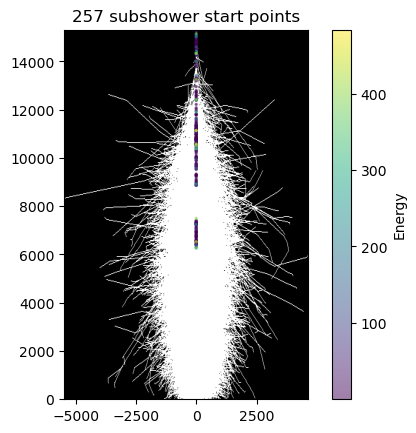

In [4]:
start_xs = reader.data["x"][outputs.shower_starts._starts]
start_zs = reader.data["z"][outputs.shower_starts._starts]
start_kes = reader.data["kinetic_energy"][outputs.shower_starts._starts]
plt.imshow(overview.grid, origin="lower", extent=extent, cmap="binary_r")
plt.scatter(start_xs, start_zs, c=start_kes, label="subshower starts", alpha=0.5, s=2)
plt.title(f"{n_subshowers} subshower start points")
cbar = plt.colorbar()
cbar.set_label("Energy")


Text(0, 0.5, 'Subshower leaves count')

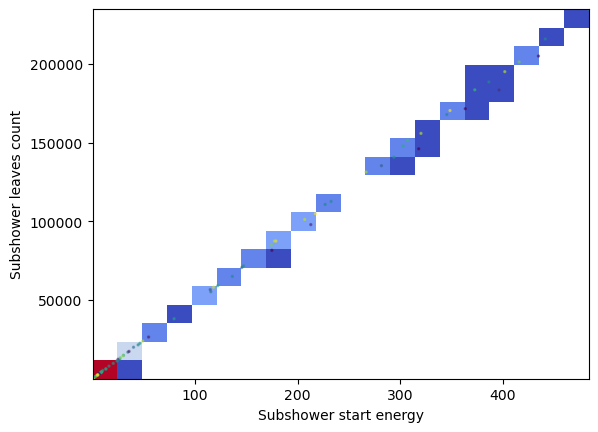

In [5]:
start_energy = []
start_height = []
n_leaves = []
for start_idx, sub in outputs.subshowers:
    start_energy.append(reader.data["kinetic_energy"][start_idx])
    start_height.append(reader.data["z"][start_idx])
    n_leaves.append(len(sub))
plt.hist2d(start_energy, n_leaves, bins=20, cmap="coolwarm", norm='log')
plt.scatter(start_energy, n_leaves, s=2, alpha=0.5, c=start_height)
plt.xlabel("Subshower start energy")
plt.ylabel("Subshower leaves count")

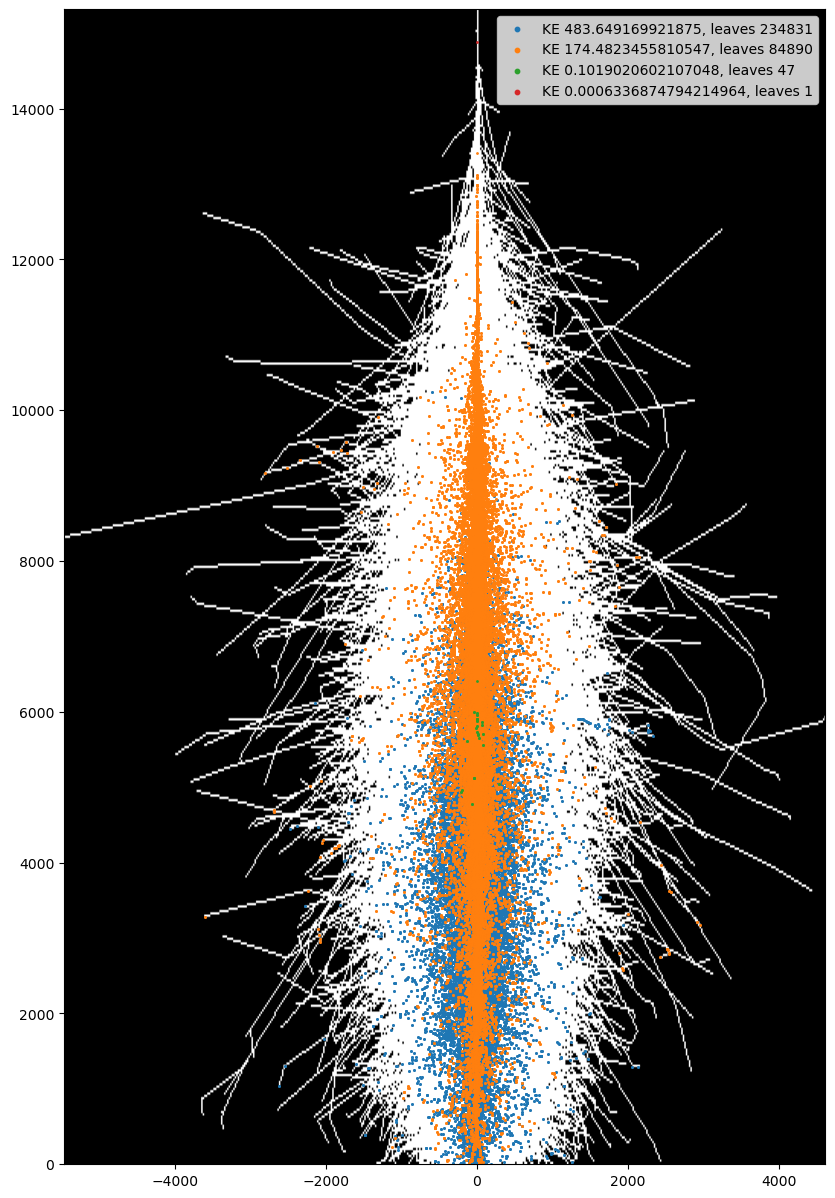

In [8]:
to_plot = [int(np.floor(p*(n_subshowers-1))) for p in [0.1, 0.5, 0.9, 1]]
to_plot = np.argsort(start_energy)[to_plot][::-1]
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
plt.imshow(overview.grid, origin="lower", extent=extent, cmap="binary_r")
for subshower_idx in to_plot:
    start_idx, subshower_leaves = outputs.subshowers[subshower_idx]
    sub_xs = reader.data["x"][subshower_leaves]
    sub_ys = reader.data["z"][subshower_leaves]
    start_kx = reader.data["kinetic_energy"][start_idx]
    n_leaves = len(sub_xs)
    pathcollection = plt.scatter(sub_xs, sub_ys, s=1)
    plt.scatter([], [], c=pathcollection.get_facecolor(), s=10, label=f"KE {start_kx}, leaves {n_leaves}")

plt.legend()